In [1]:
!pip install scikit_fuzzy

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [8]:
# Define the input variables
vehicle_speed = ctrl.Antecedent(np.arange(0, 121, 1), 'vehicle_speed')

# Define the output variable
brake_pressure = ctrl.Consequent(np.arange(0, 121, 1), 'brake_pressure')

# Define the fuzzy membership functions for vehicle_speed
vehicle_speed['slow'] = fuzz.trapmf(vehicle_speed.universe, [0, 0, 20, 40])
vehicle_speed['normal'] = fuzz.trimf(vehicle_speed.universe, [30, 60, 90])
vehicle_speed['fast'] = fuzz.trapmf(vehicle_speed.universe, [70, 90, 120, 120])

# Define the fuzzy membership functions for brake pressure
brake_pressure['none'] = fuzz.trapmf(brake_pressure.universe, [0, 0, 10, 20])
brake_pressure['low'] = fuzz.trimf(brake_pressure.universe, [10, 25, 40])
brake_pressure['medium'] = fuzz.trimf(brake_pressure.universe, [30, 50, 70])
brake_pressure['high'] = fuzz.trapmf(brake_pressure.universe, [60, 80, 120, 120])

In [15]:
rules = []

rules.append(ctrl.Rule(vehicle_speed['slow'], brake_pressure['none']))
rules.append(ctrl.Rule(vehicle_speed['slow'] & vehicle_speed['normal'], brake_pressure['low']))
rules.append(ctrl.Rule(vehicle_speed['normal'], brake_pressure['medium']))
rules.append(ctrl.Rule(vehicle_speed['normal'] & vehicle_speed['fast'], brake_pressure['medium']))
rules.append(ctrl.Rule(vehicle_speed['fast'], brake_pressure['high']))

# Create the control system
brake_pressure_ctrl = ctrl.ControlSystem(rules)

# Create a simulation
brake_pressure_simulation = ctrl.ControlSystemSimulation(brake_pressure_ctrl)

Predicted Brake Pressure: 41.3375337533753


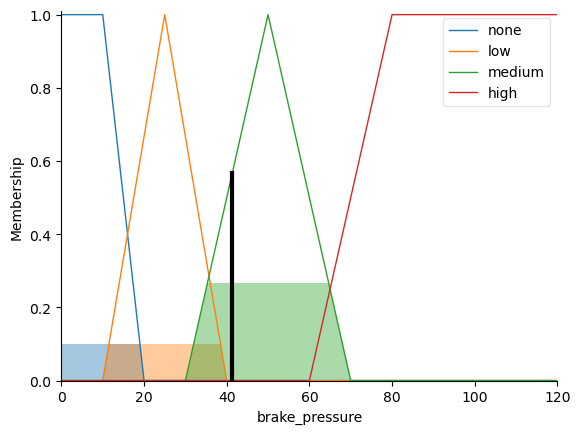

In [16]:
# Input values for prediction
brake_pressure_simulation.input['vehicle_speed'] = 38

# Compute the result
brake_pressure_simulation.compute()

# Output the result
print(f"Predicted Brake Pressure: {brake_pressure_simulation.output['brake_pressure']}")

# Visualize the result
brake_pressure.view(sim=brake_pressure_simulation)